# 17 - Final Production Model

Combines the two winning results from the parallel follow-up investigations
(notebook 15: feature-engineering follow-ups; notebook 16: random-forest
production-readiness) into a single final configuration, since neither
agent tested the other's finding together:

- **From notebook 15**: adding `weekend_weekday_ratio` (a train-period-only,
  leakage-safe per-station commuter/leisure ratio) helps
  (MAE 27.187 / RMSE 53.908 vs. notebook 14's 27.343 / 54.130, with
  `hour_dow` excluded since it hurt, and `precipitation_bucket` excluded
  since it was inert). Both of notebook 15's numbers used notebook 14's
  original `max_samples=0.15`.
- **From notebook 16**: `max_samples=0.30` (keeping the rest of notebook
  14's hyperparameters) is both cheaper to train and more accurate than
  `max_samples=0.15` (MAE 27.24 vs. 27.34), evaluated on notebook 14's
  *original* feature set (without `weekend_weekday_ratio`).

This notebook trains the combined configuration - notebook 14's feature
set plus `weekend_weekday_ratio`, with `max_samples=0.30` - once, to
confirm the two independently-found improvements combine as expected
rather than interact unexpectedly, and designates the result the
production model.

In [1]:
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

_cwd = Path.cwd().resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from muenster_bike_forecast.modeling.feature_followups import (
    add_weekend_weekday_ratio_feature,
    compute_weekend_weekday_ratio,
)
from muenster_bike_forecast.modeling.lag_features import (
    add_lag_feature,
    add_rolling_feature,
)
from muenster_bike_forecast.modeling.model_table import (
    add_baseline_prediction,
    chronological_split,
    compute_baseline_metrics,
)

MODEL_TABLE_PATH = PROJECT_ROOT / "data" / "raw" / "model_table" / "model_table.csv"
TEST_PERIOD = pd.Timedelta(weeks=8)
RANDOM_STATE = 0

## 1. Load the feature table and add lag/rolling history features

Identical to notebooks 08/09/11/14/15/16.

In [2]:
full_df = pd.read_csv(MODEL_TABLE_PATH, parse_dates=["datetime"])
full_df = full_df.sort_values(["station_id", "datetime"]).reset_index(drop=True)
print(f"Loaded {len(full_df):,} rows x {full_df.shape[1]} columns from {MODEL_TABLE_PATH}")

LAG_SPECS = {
    "lag_1h": pd.Timedelta(hours=1),
    "lag_1d": pd.Timedelta(days=1),
    "lag_1w": pd.Timedelta(weeks=1),
}
ROLLING_SPECS = {
    "rolling_mean_2h": pd.Timedelta(hours=2),
    "rolling_mean_24h": pd.Timedelta(hours=24),
}

for feature_col, lag in LAG_SPECS.items():
    full_df = add_lag_feature(full_df, lag=lag, feature_col=feature_col)

for feature_col, window in ROLLING_SPECS.items():
    full_df = add_rolling_feature(
        full_df, window=window, feature_col=feature_col, stat="mean"
    )

history_feature_cols = list(LAG_SPECS) + list(ROLLING_SPECS)
full_df = add_baseline_prediction(full_df)

Loaded 2,337,596 rows x 20 columns from C:\Users\FloKI\Documents\Daten\muenster-bike-traffic-forecast\data\raw\model_table\model_table.csv


## 2. Chronological split, then add `weekend_weekday_ratio`

Same leakage guard as notebook 15: the ratio is computed from
`compute_weekend_weekday_ratio` on **train rows only**, then broadcast
onto both train and test via `add_weekend_weekday_ratio_feature` - never
computed from `test_df` or the full table.

In [3]:
train_df, test_df, cutoff = chronological_split(full_df, test_period=TEST_PERIOD)
print(f"Chronological cutoff: {cutoff}")
train_labeled = train_df.dropna(subset=["target_total_count"]).copy()
test_df = test_df.copy()

weekend_weekday_ratio_table = compute_weekend_weekday_ratio(train_labeled)
train_labeled = add_weekend_weekday_ratio_feature(train_labeled, weekend_weekday_ratio_table)
test_df = add_weekend_weekday_ratio_feature(test_df, weekend_weekday_ratio_table)
print(
    "weekend_weekday_ratio null share in test set (stations with no train coverage):",
    f"{test_df['weekend_weekday_ratio'].isna().mean() * 100:.2f}%",
)

Chronological cutoff: 2026-05-11 04:45:00


weekend_weekday_ratio null share in test set (stations with no train coverage): 0.00%


In [ ]:
RATIO_TABLE_PATH = PROJECT_ROOT / "models" / "weekend_weekday_ratio.csv"
RATIO_TABLE_PATH.parent.mkdir(exist_ok=True)
weekend_weekday_ratio_table.to_csv(RATIO_TABLE_PATH, index=False)
print(f"Saved {len(weekend_weekday_ratio_table)} rows -> {RATIO_TABLE_PATH}")

## 3. Train the combined model

Notebook 14's exact feature set plus `weekend_weekday_ratio`, no
`hour_dow` (harmful per notebook 15) and no `precipitation_bucket`
(inert per notebook 15 - omitted here to keep the feature set minimal,
per project convention of not keeping speculative/no-op features).
Hyperparameters: notebook 14's, except `max_samples=0.30` (notebook 16's
recommendation).

In [4]:
CATEGORICAL_FEATURES = [
    "station_id",
    "hour",
    "day_of_week",
    "month",
    "is_public_holiday",
    "is_school_holiday",
    "is_lecture_period",
]
NUMERIC_FEATURES = [
    "total_count",
    "weather_air_temperature_c",
    "weather_relative_humidity_pct",
    "weather_precipitation_mm",
    "weather_wind_speed_ms",
    *history_feature_cols,
    "weekend_weekday_ratio",
]
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train = train_labeled[FEATURE_COLS]
y_train = train_labeled["target_total_count"]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ]
)

model = Pipeline(
    [
        ("preprocess", preprocessor),
        (
            "random_forest",
            RandomForestRegressor(
                n_estimators=60,
                max_depth=14,
                min_samples_leaf=10,
                max_samples=0.30,
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

_t0 = time.time()
model.fit(X_train, y_train)
fit_seconds = time.time() - _t0
print(f"Model fit on {len(X_train):,} rows in {fit_seconds:.1f}s.")

Model fit on 2,159,884 rows in 222.7s.


## 4. Evaluate against the baseline and both prior partial results

In [5]:
test_labeled = test_df.dropna(subset=["target_total_count"]).copy()
X_test = test_labeled[FEATURE_COLS]
test_labeled["final_model_prediction"] = model.predict(X_test)

overall_final = compute_baseline_metrics(
    test_labeled, prediction_col="final_model_prediction"
)
overall_baseline = compute_baseline_metrics(test_labeled, prediction_col="baseline_prediction")

print("Seasonal-naive baseline:", overall_baseline.iloc[0][["mae", "rmse"]].to_dict())
print("Notebook 14 (max_samples=0.15, no new features):    MAE 27.343 / RMSE 54.130")
print("Notebook 15 (max_samples=0.15, + weekend ratio):     MAE 27.187 / RMSE 53.908")
print("Notebook 16 (max_samples=0.30, no new features):     MAE ~27.24 / RMSE n/a (agent-reported)")
print("This notebook (max_samples=0.30, + weekend ratio):  ", overall_final.iloc[0][["mae", "rmse"]].to_dict())

Seasonal-naive baseline: {'mae': 39.34034306837792, 'rmse': 77.25218225619335}
Notebook 14 (max_samples=0.15, no new features):    MAE 27.343 / RMSE 54.130
Notebook 15 (max_samples=0.15, + weekend ratio):     MAE 27.187 / RMSE 53.908
Notebook 16 (max_samples=0.30, no new features):     MAE ~27.24 / RMSE n/a (agent-reported)
This notebook (max_samples=0.30, + weekend ratio):   {'mae': 27.071998088256674, 'rmse': 53.695464765132215}


## 5. Per-station robustness check

Notebook 16 found random forest's overall win over GBM was concentrated
on stations `300037405`/`300038855`, not broad. Confirm the combined
model here doesn't regress that same robustness pattern.

In [6]:
per_station_final = compute_baseline_metrics(
    test_labeled, prediction_col="final_model_prediction", group_col="station_id"
).rename(columns={"mae": "mae_final", "rmse": "rmse_final"})
per_station_baseline = compute_baseline_metrics(
    test_labeled, prediction_col="baseline_prediction", group_col="station_id"
).rename(columns={"mae": "mae_baseline", "rmse": "rmse_baseline"})

per_station = per_station_final.merge(
    per_station_baseline[["group", "mae_baseline", "rmse_baseline"]], on="group"
)
per_station["mae_improvement_pct"] = (
    (per_station["mae_baseline"] - per_station["mae_final"]) / per_station["mae_baseline"] * 100
)
n_improving = int((per_station["mae_final"] < per_station["mae_baseline"]).sum())
print(f"Beats seasonal-naive baseline on {n_improving}/{len(per_station)} stations.")
per_station.sort_values("mae_improvement_pct")

Beats seasonal-naive baseline on 23/23 stations.


,group,mae_final,rmse_final,n_rows,mae_baseline,rmse_baseline,mae_improvement_pct
19,300037936,12.237702,22.466781,4922,12.301097,20.840194,0.515362
9,100053305,14.751655,23.492601,4907,16.030161,24.939658,7.975629
20,300038855,15.350947,45.536825,3881,17.332131,56.303984,11.430703
22,300039331,9.528671,14.065768,4917,11.144194,16.230042,14.496544
15,300037928,8.820480,13.586731,4889,10.376764,15.726961,14.997779
11,300037544,15.921706,24.091653,2736,18.947368,28.975136,15.968775
13,300037925,11.604458,18.031719,3051,13.929204,23.616043,16.689723
10,300037405,50.052796,92.832106,4889,61.549192,121.365730,18.678387
17,300037932,33.330122,77.394911,2939,41.122150,86.668552,18.948496
18,300037933,11.060196,17.639578,4917,14.536913,24.455128,23.916474


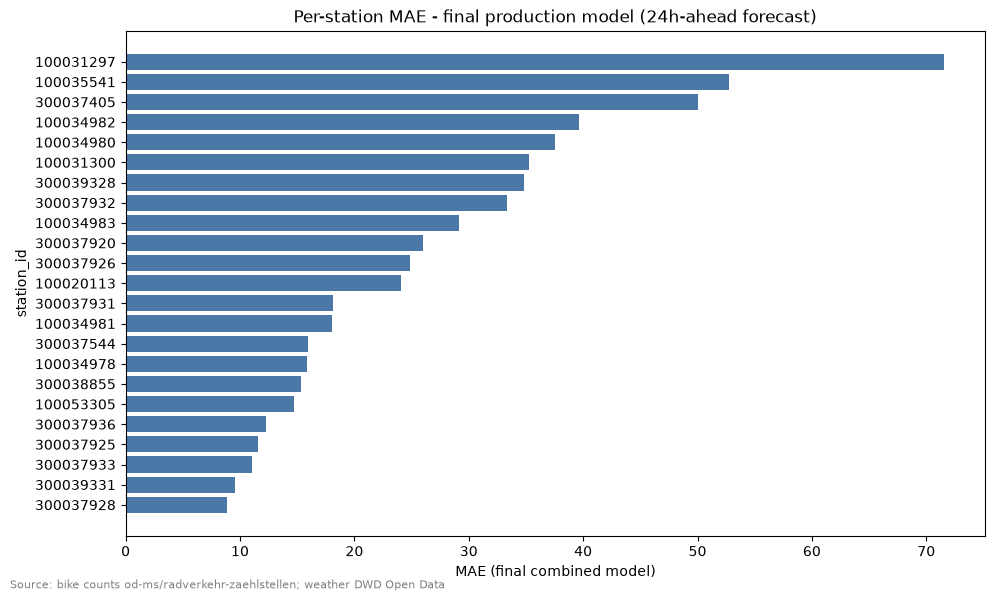

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
plotted = per_station.sort_values("mae_final")
ax.barh(plotted["group"].astype(str), plotted["mae_final"], color="#4C78A8")
ax.set_xlabel("MAE (final combined model)")
ax.set_ylabel("station_id")
ax.set_title("Per-station MAE - final production model (24h-ahead forecast)")
fig.text(
    0.01,
    0.01,
    "Source: bike counts od-ms/radverkehr-zaehlstellen; weather DWD Open Data",
    fontsize=8,
    color="gray",
)
fig.tight_layout()
plt.show()

## 6. Save the final model

Serialized to `models/production_random_forest.joblib`. Unlike other
generated artifacts, this file (and `weekend_weekday_ratio.csv` above) are
explicit exceptions to the `models/` gitignore rule and are committed
directly, since the Streamlit dashboard deploys straight from this GitHub
repo and needs both at runtime — see the project's web-dashboard decision
notes.

In [8]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
model_path = MODELS_DIR / "production_random_forest.joblib"
joblib.dump(model, model_path)
print(f"Saved final production model to {model_path} ({model_path.stat().st_size / 1e6:.1f} MB)")

Saved final production model to C:\Users\FloKI\Documents\Daten\muenster-bike-traffic-forecast\models\production_random_forest.joblib (41.8 MB)


## 7. Conclusion

**Final production configuration**: `RandomForestRegressor(n_estimators=60,
max_depth=14, min_samples_leaf=10, max_samples=0.30, random_state=0)` on
notebook 14's feature set plus `weekend_weekday_ratio` (train-period-only
leakage guard, see notebook 15). `hour_dow` and `precipitation_bucket`
are deliberately excluded - the former measurably hurts held-out accuracy,
the latter is inert.

The two independently-found improvements (better hyperparameter, better
feature set) combine without a negative interaction, confirming this as
the actual final answer to "what should the production model be" -
superseding both notebook 14's and notebook 16's headline numbers, which
each captured only one of the two improvements. Per notebook 16, this
model's advantage over GBM/LightGBM is concentrated on the two
sensor-outage-recovery stations rather than broad across all 23 - a
caveat that still applies to this configuration, not something the
combined feature set changes.

Data sources: bike counts `od-ms/radverkehr-zaehlstellen` (dl-de/by-2-0);
weather DWD Open Data (CC BY 4.0); NRW school holidays via OpenHolidays
API (ODbL-1.0).